In [1]:
import sys
import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group
from datetime import datetime

In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
dataset = datasets.construct("imagenet-butterfly")

In [6]:
ds_train = dataset.create_subset(train_split=True)
ds_val = dataset.create_subset(train_split=False)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|███████████| 7800/7800 [00:00<00:00, 847817.23it/s]


We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████| 300/300 [00:00<00:00, 813375.05it/s]


In [7]:
MODEL_NAME = "imagenet-vgg16-tv"

MAIN_LAYER = "features.30"
# MODEL_NAME = "imagenet-resnet50-tv"

In [8]:
teacher = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(teacher, dataset.selected_classes)

teacher.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [9]:
teacher.features[0].bias.shape

torch.Size([64])

In [10]:
torch.flatten(torch.tensor(np.arange(9)).reshape(1, 1, 3, 3), 1)

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8]])

In [11]:
teacher.classifier[0]

Linear(in_features=25088, out_features=4096, bias=True)

In [12]:
class MyConv(torch.nn.Module):
    def __init__(self, layer):
        super().__init__()
        weight = layer.weight
        self.bias = layer.bias
        self.weight = weight.reshape((4096, 512, 7, 7))

    def forward(self, x):
        n, d = x.shape
        
        x = x.reshape(n, 512, 7, 7)
        
        output = F.conv2d(x, self.weight, bias=self.bias)

        return torch.flatten(output, start_dim=1)
# MyConv(teacher.classifier[0])

from copy import deepcopy
@torch.no_grad()
def sanity_check():
    torch.manual_seed(1)
    din = 512
    dout = 4096
    w = 7
    dummy_output = torch.randn((1, din*w*w)).to(device)

    # teacher_mod = torch.nn.Linear(in_features=din*w*w, out_features=dout)
    teacher_mod = deepcopy(teacher.classifier[0])
    # .to("cpu")

    # teacher_mod.bias = torch.nn.Parameter(torch.zeros_like(teacher_mod.bias))
    
    output = teacher_mod(dummy_output)
    
    conv = MyConv(teacher_mod)
    actual = conv(dummy_output)
    
    np.testing.assert_allclose(
        actual.cpu().numpy(),
        output.cpu().numpy(),
        atol=1e-3
    )    
    print("Sanity Check: loca passed")

    dummy = torch.randn((5, 3, 224, 224)).to(device)
    copied_teacher = deepcopy(teacher)
    copied_teacher.classifier[0] = MyConv(teacher.classifier[0])

    np.testing.assert_allclose(
        copied_teacher(dummy).cpu().numpy(),
        teacher(dummy).cpu().numpy(),
        atol=1e-3
    )
    print("Sanity Check: whole module passed ")

    return copied_teacher

copied_teacher = sanity_check()

Sanity Check: loca passed
Sanity Check: whole module passed 


In [13]:
# teacher = copied_teacher 

In [14]:
# def viz_singular_values():
#     arr_layer_ixs = [0, 3, 6]
#     ncols = len(arr_layer_ixs)
#     nrows = 2
#     plt.figure(figsize=(3*ncols, 2*nrows))
    
#     plt.suptitle(MODEL_NAME, y=1.1)
#     for ix, lix in enumerate(arr_layer_ixs):
#         plt.subplot(nrows, ncols, ix + 1)
#         plt.title(f"classifier.{lix}")
#         weight = teacher.classifier[lix].weight
#         _, S, _ = torch.svd(weight, some=True, compute_uv=False)
        
#         plt.plot(
#             S.detach().cpu().numpy()
#         )
#         if ix == 0:
#             plt.ylabel("Singular Values")

#         plt.subplot(nrows, ncols, ncols + ix + 1)
#         plt.hist(teacher.classifier[lix].bias.detach().cpu().numpy())
# viz_singular_values()

In [15]:
# def truncate_model():
#     arr_layer_ixs = [0, 3]
#     K = 100
#     for lix in arr_layer_ixs:
#         weight = teacher.classifier[lix].weight
#         U, S, Vh = torch.linalg.svd(weight, full_matrices=False)
#         new_weight = U[:, :K] @ torch.diag(S[:K]) @ Vh[:K, :]
#         print(weight.shape, U.shape, S.shape, Vh.shape)
#         print("new_weight.shape", new_weight.shape)
#         teacher.classifier[lix].weight = torch.nn.Parameter(new_weight)

# truncate_model()  

In [16]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [17]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [18]:
teacher_acc, _ = metrics.accuracy(
    teacher,
    dataloader=datasets.build_dataloader(ds_val, shuffle=False),
    num_classes=dataset.num_classes,
    device=device,
)
teacher_acc

0.9599999785423279

In [19]:
def make_attributor_for(
    model,
    input_statistics,
    gamma,
    epsilon,
):
    input_transform = transforms.Normalize(*input_statistics)

    low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    if isinstance(model, models.resnet.resnet.ResNet):
        canonizers = [ResNetCanonizer()]
    else:
        canonizers = []

    print(f"Instantiating EpsilonGammaBox(gamma={gamma}, eps={epsilon})")

    composite = EpsilonGammaBox(low=low, high=high, canonizers=canonizers, gamma=gamma, epsilon=epsilon)

    print(f"Composite={composite}")
    attributor = Gradient(
        model=model, 
        composite=composite
    )


    return attributor


    
def extract_activation_context(
    model,
    layer,
    dataset,
    data_loader,
    logit_modifier,
    rng,
    gamma=0.25,
    eps=1e-6,
    device="cpu",
    number_of_selected_spatial_locations=20,
    verbose=False
):
    arr_act = []
    arr_ctx = []

    
    with make_attributor_for(model, dataset.input_statistics, gamma=gamma, epsilon=eps) as attributor:
        for batch in tqdm(data_loader):
            x, y = batch
            x = x.to(device)

            try:
                module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                    model, layer, should_retain_grad=True
                )

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad
                

                output_dimensions = act.shape[1:]
                # print("output.dimension", output_dimensions)
                # todo: check this with Gregoire again!
                ctx = torch.where(
                    act.abs() > 0, 
                    rel / act, 
                    0
                )

                np.testing.assert_allclose(
                    (act * ctx).detach().cpu().numpy(), 
                    (rel * (act.abs() > 0)).detach().cpu().numpy(),
                    atol=1e-6
                )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                if len(act.shape) == 2:
                    act = act[:, :, None, None]
                    ctx = ctx[:, :, None, None]

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

            finally:
                hook.remove()
    if verbose:
        print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


GAMMA = 0.25

def get_act_ctx(model, dataset, layer, gamma, eps=1e-6, verbose=False):

    logit_modifier = attributors.WinningClassEvidence(num_classes=len(dataset.selected_classes))
    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False
    )
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        gamma=gamma,
        eps=eps,
        verbose=verbose,
    )


_arr_act, _arr_ctx = get_act_ctx(
    teacher,
    dataset,
    gamma=GAMMA,
    layer=MAIN_LAYER, 
    verbose=False
)

Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)
Composite=<zennit.composites.EpsilonGammaBox object at 0x7f6617f80880>


100%|████████████████████████████████████████████████████████| 122/122 [01:23<00:00,  1.46it/s]


In [20]:
dataset.selected_classes

[321, 322, 323, 324, 325, 326]

max 0.8074216880867838 27
min -0.372380236683142 15


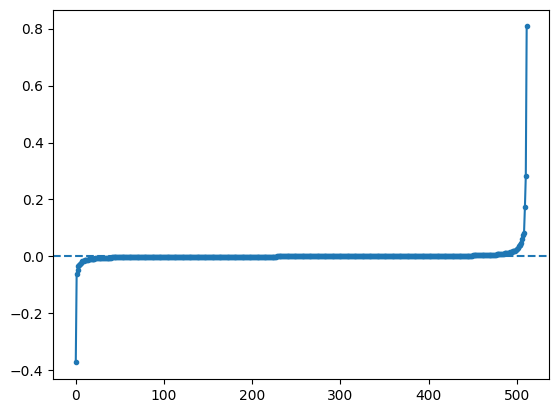

In [21]:
def viz_eigvals():
    ccov = _arr_act.T @ _arr_ctx + _arr_ctx.T @ _arr_act
    ccov = ccov / _arr_act.shape[0]
    
    eigvals, eigvecs = np.linalg.eigh(ccov)
    print("max", np.max(eigvals), (eigvals > 0.01 ).sum())
    print("min", np.min(eigvals), (eigvals < -0.01 ).sum())
    plt.plot(eigvals, marker=".")
    plt.axhline(0, ls="--")
    
    
viz_eigvals()

In [22]:
def solve_pca(arr_act, arr_ctx):
    _, pca_eigvecs = np.linalg.eigh(arr_act.T @ arr_act)
    U = np.flip(pca_eigvecs, axis=1).copy()
    return U.copy()

def solve_prca(arr_act, arr_ctx):
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

    eigvals, eigvecs = np.linalg.eigh(ccov)

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-np.abs(eigvals))

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()


def solve_pca_on_ctx(arr_act, arr_ctx, ascending=True):
    ccov = arr_ctx.T @ arr_ctx 

    eigvals, eigvecs = np.linalg.eigh(ccov)

    assert eigvals.shape == (arr_act.shape[1], )

    if ascending:
        indices = np.argsort(eigvals)
    else:
        indices = np.argsort(-eigvals)
        
    U = np.copy(eigvecs[:, indices])
    
    return U.copy()


def solve_prcaraw(arr_act, arr_ctx):
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

    eigvals, eigvecs = np.linalg.eigh(ccov)

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-eigvals)

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()

def solve_prcanorm(arr_act, arr_ctx):
    arr_act = arr_act / np.linalg.norm(arr_act, axis=1, keepdims=True)
    arr_ctx = arr_ctx / np.linalg.norm(arr_ctx, axis=1, keepdims=True)
    
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

    eigvals, eigvecs = np.linalg.eigh(ccov)

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-np.abs(eigvals))

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()

def solve(method, arr_act, arr_ctx):
    if method == "pca":
        return solve_pca(arr_act, arr_ctx)
    elif method == "prca":
        return solve_prca(arr_act, arr_ctx)
    elif method == "pca_on_ctx_asc":
        return solve_pca_on_ctx(arr_act, arr_ctx, ascending=True)
    elif method == "pca_on_ctx_desc":
        return solve_pca_on_ctx(arr_act, arr_ctx, ascending=False)
    elif method == "prcaraw":
        return solve_prcaraw(arr_act, arr_ctx)
    elif method == "prcanorm":
        return solve_prcanorm(arr_act, arr_ctx)
    elif "pcak" in method:
        k = int(method.split(":")[0].replace("pcak", ""))
        
        Ua = solve_pca(arr_act, None)[:, :k]
        Uprca = solve_prca(arr_act @ Ua, arr_ctx @ Ua)
        
        return Ua @ Uprca
      
    # elif method == "pcak32:prca":
    #     Upca = solve_pca(arr_act, arr_ctx)[:, :32]
    #     Uprca = solve_prca(arr_act, arr_ctx @ Upca @ Upca.T)
    #     return Uprca
    # elif method == "pcak64:prca":
    #     Upca = solve_pca(arr_act, arr_ctx)[:, :64]
    #     Uprca = solve_prca(arr_act, arr_ctx @ Upca @ Upca.T)
    #     U = Uprca
    #     # np.testing.assert_allclose(
    #     #     U[:, :5],
    #     #     Upca @ Uprca[:, :5],
    #     #     atol=1e-6
    #     # )
    #     return U

    else:
        raise ValueError(f"{method} doesn't exist!")

def ano():

    for method in ["prca", "pca_on_ctx_asc", "pca_on_ctx_desc"]:
        solve(method, _arr_act, _arr_ctx)
    print(">>>>>>>")
ano()

>>>>>>>


In [23]:
# def viz_recon_at_k():
#     arr_ks = [1, 2, 4, 8, 16, 32, 64]
#     ncols = 2

#     arr_act = _arr_act
#     arr_ctx = _arr_ctx

#     plt.figure(figsize=(4*2, 3))
#     plt.suptitle(f"{MODEL_NAME}-{MAIN_LAYER}")
#     def recon_at_k(mat, k):
#         Uk = U[:, :k]
#         mat_recon = mat @ Uk @ Uk.T
    
#         return np.linalg.norm(
#             (mat_recon - mat),
#             axis=1
#         ).mean()

#     for i, (col, mat) in enumerate([("act", arr_act), ("ctx", arr_ctx)]):
#         plt.subplot(1, ncols, i+1)
#         plt.title(col)
#         if i == 0:
#             plt.ylabel("recon err.")

        
#         for mix, method in enumerate(["pca", "prca", "pcak16:prca", "pcak32:prca", "pcak64:prca"]):
#             U = solve(method, arr_act, arr_ctx)
      
        
#             arr_stats = [] 
            
#             for i, k in enumerate(arr_ks):
#                 arr_stats.append(recon_at_k(mat, k))
        
#             plt.plot(arr_ks, arr_stats, marker="." if method in ["pca", "prca"] else "*", label=method)
#         plt.legend()

# viz_recon_at_k()

In [24]:
@torch.no_grad()
def decorrelate(A: torch.Tensor) -> torch.Tensor:
    # U_ = U @ (U.T @ U)^{-1/2}
    # ref: Hyvärinen et al. (2003), Independent Component Analysis, eq 6.37

    S = A.T @ A
    # somehow, for some classes (e.g. basketball at nfnet-f0's stage1),
    # the eigenvalue decomposition fails if using float.
    # Using double makes it more stable but slightly decreases the speed.
    # See: https://gist.github.com/p16i/4a37e10230c016fcde6c0e571c9ae010
    D, E = torch.linalg.eigh(S.double())
    D = D.float()
    E = E.float()

    inv = E @ torch.diag(1 / (torch.pow(D, 0.5))) @ E.T

    return A @ inv

In [25]:


def compute_accuracy_with_Uk(
    model, layer, Uk, dataset, dl
):
    module = utils.interceptor.get_module(model, layer)

    UUT, hook_func = fh_low_rank(Uk)
    hook = module.register_forward_hook(hook_func)

    try:
        acc, _ = metrics.accuracy(
                        model,
                        dataloader=dl,
                        num_classes=dataset.num_classes,
                        device=device,
                )
        
    finally:
        hook.remove()
        del UUT
    return acc  


In [26]:

def fh_low_rank(U):
    d, k = U.shape

    assert k <= d

    UUT = U @ U.T 
    assert UUT.shape == (d, d)

    UUT = torch.from_numpy(UUT).float().unsqueeze(2).unsqueeze(3).to(device)
    
    def do(module, inp, out):
        inp, = inp

        shape = out.shape
        if len(shape) == 2:
           out = out.unsqueeze(2).unsqueeze(3)
        
        out2 = F.conv2d(out, UUT)

        if k == d and False:
            np.testing.assert_allclose(
                out.detach().cpu().numpy(), out2.detach().cpu().numpy(),
                atol=1e-3
            )

        out2 = out2.reshape(shape)
        
        return out2

    return UUT, do 

In [27]:
from collections import OrderedDict

In [28]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [29]:
from torchvision.models import VGG, ResNet

In [30]:
# def flatten_layers(model):
#     # build all layer names

#     if isinstance(model, VGG):
    
#         layers = []
#         for lix, layer in enumerate(model.features.children()):
#             slug = f"features:{lix}"
            
#             layers.append((slug, layer))
        
#         layers.append(("avgpool", model.avgpool))
#         layers.append(("flatten", torch.nn.Flatten(start_dim=1)))
    
        
#         for lix, layer in enumerate(model.classifier.children()):
#             slug = f"classifier:{lix}"
            
#             layers.append((slug, layer))

#     elif isinstance(model, ResNet):
#         layers = [
#             ("conv1", model.conv1),
#             ("bn1", model.bn1),
#             ("relu", model.relu),
#             ("maxpool", model.maxpool),
#             ("layer1", model.layer1),
#             ("layer2", model.layer2),
#             ("layer3", model.layer3),
#             ("layer4", model.layer4),
#             ("avgpool", model.avgpool),
#             ("flatten", torch.nn.Flatten(start_dim=1)),
#             ("fc", model.fc)
#         ]
        
    
#     return torch.nn.Sequential(OrderedDict(layers))

# @torch.no_grad()
# def sanity_check():

#     new_module = flatten_layers(teacher)

#     x = torch.rand(8, 3, 224, 224).to(device)
#     expected = teacher(x).detach().cpu().numpy()
#     actual = new_module(x).detach().cpu().numpy()

#     np.testing.assert_allclose(actual, expected)
#     print("sanity check: passed!")
#     return new_module
# sanity_check()

In [31]:
# def get_module_names(flatten_model):
#     name = list(map(lambda n: n[0], flatten_model.named_modules()))

#     if isinstance(teacher, VGG):
        
#         return list(filter(lambda x: x, name))
#     elif isinstance(teacher, ResNet):
#         return list(filter(lambda x: "." not in x and x, name))
# get_module_names(flatten_layers(teacher))

In [32]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [33]:
MODEL_NAME, MAIN_LAYER

('imagenet-vgg16-tv', 'features.30')

['pca', 'prca', 'pca_on_ctx_asc', 'pca_on_ctx_desc']


  0%|                                                                    | 0/6 [00:00<?, ?it/s]

basis_name=pca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=prca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_asc; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_desc; layer=features.30; model_name=imagenet-vgg16-tv


 17%|██████████                                                  | 1/6 [00:09<00:45,  9.07s/it]

basis_name=pca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=prca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_asc; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_desc; layer=features.30; model_name=imagenet-vgg16-tv


...

basis_name=pca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=prca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_asc; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_desc; layer=features.30; model_name=imagenet-vgg16-tv


 83%|██████████████████████████████████████████████████          | 5/6 [00:46<00:09,  9.31s/it]

basis_name=pca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=prca; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_asc; layer=features.30; model_name=imagenet-vgg16-tv
basis_name=pca_on_ctx_desc; layer=features.30; model_name=imagenet-vgg16-tv


100%|████████████████████████████████████████████████████████████| 6/6 [00:55<00:00,  9.26s/it]


,layer,k,basis_name,acc_val
0,features.30,1,pca,0.133333
1,features.30,1,prca,0.166667
2,features.30,1,pca_on_ctx_asc,0.156667
3,features.30,1,pca_on_ctx_desc,0.176667
4,features.30,2,pca,0.440000
5,features.30,2,prca,0.180000
6,features.30,2,pca_on_ctx_asc,0.113333
7,features.30,2,pca_on_ctx_desc,0.210000
8,features.30,4,pca,0.736667
9,features.30,4,prca,0.493333


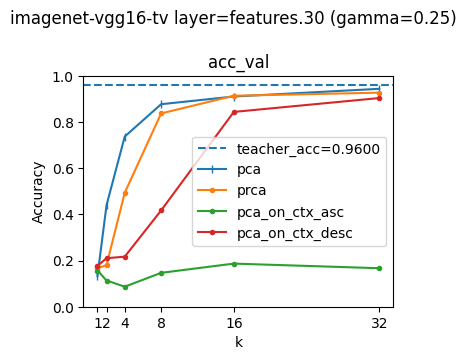

In [34]:
import matplotlib as mpl


def compute_accuracy_of_basis_at_k(
    model, dataset, layer, 
    arr_ks,
    arr_bases,
):
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)
    dl_train = datasets.build_dataloader(ds_train, shuffle=False)    
    
    rows = []
    print(arr_bases)
    for k in tqdm(arr_ks):
        for basis_name in arr_bases:
            Uk = estimate_basis(
                layer=layer,
                basis_name=basis_name, 
                k=k
            )
            acc_val = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_val)
#             acc_train = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_train)

            rows.append(
                    dict(
                        layer=layer, k=k, 
                        basis_name=basis_name,
                        acc_val=acc_val,
#                         acc_train=acc_train
                    )
            )
    

    df = pd.DataFrame(rows)

    return df



def estimate_basis(layer, basis_name, k):
    print(f"basis_name={basis_name}; layer={MAIN_LAYER}; model_name={MODEL_NAME}")

    U = solve(basis_name, _arr_act, _arr_ctx)[:, :k]
    return U
    
def estimate_rank_k_accuracies(
    model, dataset, layer,
    arr_bases=[
        "pca",
        "prca",
        # "prcaraw",
        "pca_on_ctx_asc",
        "pca_on_ctx_desc"
        # "prcanorm",
        # "pcak8:prca",
        # "pcak16:prca",
        # "pcak32:prca",
        # "pcak64:prca",
    ],
    arr_ks=[1,2, 4, 8, 16, 32],
):

    colors = mpl.cm.Blues
    nbases = len(arr_bases)

    df = compute_accuracy_of_basis_at_k(
        model, dataset, layer, 
        arr_bases=arr_bases,
        arr_ks=arr_ks
    )

    torch.cuda.empty_cache()

    def alias(name):
        return name
        if name == "pca":
            return "PCA"
        elif "prcaopt:" in name:
            _, slug = name.split(":")
            return f"PCA-LH:{slug}"
        else:
            raise
            
    def ls(name):
        if name == "prcasortabs-penu":
            return "--"
        else:
            return "-"

    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prcaopt":
            return "red"
        else:
            return None
            

    cols = [
#         "acc_train", 
        "acc_val"
    ]
    ncols = len(cols)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(f"{MODEL_NAME} layer={layer} (gamma={GAMMA})", y=1.1)

    for cix, col in enumerate(cols):
        plt.subplot(1, ncols, cix+1)
        plt.title(col)
        plt.axhline(teacher_acc, ls="--", label=f"teacher_acc={teacher_acc:.4f}")
        for nix, name in enumerate(df.basis_name.unique()):
            _df = df[df.basis_name == name]
            
            plt.plot(
                _df.k, 
                _df[col],
                label=alias(name),
                ls=ls(name),
                marker="|" if name == "pca"  else ".",
#                 color=color(name) if name in ["pca", "prcaopt"] else colors((nix+0.1)/nbases) 
            )
    
        plt.ylim([0, 1])
        plt.legend()
        plt.ylabel("Accuracy"); plt.xlabel("k")
        plt.xticks(df.k.unique())
    
    return df
    
estimate_rank_k_accuracies(model=teacher, dataset=dataset, layer=MAIN_LAYER)

In [35]:
print(f"Finished at {datetime.now()}")

Finished at 2024-05-06 20:51:07.941866
